# Train and Visualize a Segmentation Experiment

This notebook is the interactive workflow for training a config, evaluating it on a heldout split, and visualizing predictions. It defaults to `synthetic_debug` so a fresh run is quick and does not require a long FTW training job.

In [22]:
from pathlib import Path
import os
import sys

# Colab users: run this cell first. It mounts Drive and changes into the
# code-only project folder, so imports like `from cfgs import ...` work.
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root(start):
    for path in [start, *start.parents]:
        if (path / 'cfgs').is_dir() and (path / 'src').is_dir():
            return path

    candidate_roots = [
        Path('/content/drive/MyDrive/HLCV_final_project'),
        Path('/content/HLCV_final_project'),
    ]
    for candidate in candidate_roots:
        if (candidate / 'cfgs').is_dir() and (candidate / 'src').is_dir():
            return candidate

    raise FileNotFoundError(
        'Could not find HLCV_final_project. Put the code-only project folder '
        'in /content/drive/MyDrive/HLCV_final_project, or edit candidate_roots '
        'in this cell to match your Drive folder.'
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Using project root: {PROJECT_ROOT}')
print('Now run: %pip install -r requirements.txt if this is a fresh Colab runtime.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using project root: /content/drive/My Drive/HLCV_final_project
Now run: %pip install -r requirements.txt if this is a fresh Colab runtime.


In [23]:
# Run this once in a fresh Colab runtime, after the project-root cell above.
%pip install -q -r requirements.txt

In [24]:
# Optional: run this in Colab if you keep a zipped FTW subset in Google Drive.
# Change this path if your zip has a different name or Drive folder.
from pathlib import Path
import subprocess
import shutil

FTW_ZIP = Path('/content/drive/MyDrive/ftw_france_subset.zip')
LOCAL_DATA_ROOT = Path('/content/data')
FTW_COUNTRY = 'france'
LOCAL_FTW_ROOT = LOCAL_DATA_ROOT / 'ftw'
LOCAL_COUNTRY_DIR = LOCAL_FTW_ROOT / FTW_COUNTRY

def has_ftw_country_payload(path, country=FTW_COUNTRY):
    path = Path(path)
    return (
        path.is_dir()
        and (path / 's2_images').is_dir()
        and (path / 'label_masks').is_dir()
        and ((path / f'chips_{country}.parquet').exists() or (path / 's2_images' / 'window_a').is_dir())
    )

def normalize_ftw_country_folder(source_dir, country=FTW_COUNTRY):
    source_dir = Path(source_dir)
    target_dir = LOCAL_FTW_ROOT / country
    if source_dir.resolve() == target_dir.resolve():
        return target_dir.parent
    target_dir.mkdir(parents=True, exist_ok=True)
    for name in [f'chips_{country}.parquet', 's2_images', 'label_masks']:
        src = source_dir / name
        dst = target_dir / name
        if src.exists() and not dst.exists():
            shutil.move(str(src), str(dst))
    return target_dir.parent

def find_ftw_data_root(search_root=LOCAL_DATA_ROOT, country='france'):
    search_root = Path(search_root)
    if not search_root.exists():
        return None
    for candidate in [search_root / 'ftw' / country, search_root / country, search_root]:
        if has_ftw_country_payload(candidate, country):
            return normalize_ftw_country_folder(candidate, country)
    for country_dir in search_root.rglob(country):
        if (
            country_dir.is_dir()
            and (country_dir / 's2_images').is_dir()
            and (country_dir / 'label_masks').is_dir()
        ):
            return normalize_ftw_country_folder(country_dir, country)
    for parquet in search_root.rglob(f'chips_{country}.parquet'):
        country_dir = parquet.parent
        if (country_dir / 's2_images').is_dir() and (country_dir / 'label_masks').is_dir():
            return normalize_ftw_country_folder(country_dir, country)
    return None

if IN_COLAB:
    if FTW_ZIP.exists():
        LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)
        if find_ftw_data_root() is None:
            subprocess.run(['unzip', '-q', str(FTW_ZIP), '-d', str(LOCAL_DATA_ROOT)], check=True)
        ftw_data_root = find_ftw_data_root()
        if ftw_data_root is None:
            print(f'Unzipped {FTW_ZIP}, but could not find an FTW france folder under {LOCAL_DATA_ROOT}.')
            print('Run: !find /content/data -maxdepth 6 -type d | sort | head -80')
        else:
            print(f'FTW data root for config: {ftw_data_root}')
    else:
        print(f'Skipping FTW unzip because this file was not found: {FTW_ZIP}')
        print('Upload your FTW subset zip to Drive or update FTW_ZIP in this cell.')
else:
    print('Not running in Colab; using local project/data paths.')

FTW data root for config: /content/data/ftw


## Setup

Change `CONFIG_NAME` to `ftw_mask_baseline` or `ftw_dual_head` for real FTW experiments. Keep `NOTEBOOK_NUM_WORKERS = 0` unless you specifically want multiprocessing in the notebook kernel.

In [25]:
from copy import deepcopy

from cfgs import field_segmentation
from src.utils.utils import seed_everything
from src.utils.visualization import show_batch, show_predictions

CONFIG_NAME = 'ftw_mask_baseline'  # options: synthetic_debug, ftw_mask_baseline, ftw_dual_head
NOTEBOOK_NUM_WORKERS = 0
MAX_NOTEBOOK_EPOCHS = 10  # set to an integer to override the config while experimenting

seed_everything(0)
config = deepcopy(getattr(field_segmentation, CONFIG_NAME))
if 'data_dir' in config['data_args']:
    local_ftw_root = find_ftw_data_root() if 'find_ftw_data_root' in globals() else None
    if local_ftw_root is not None:
        config['data_args']['data_dir'] = str(local_ftw_root)
        print(f"Using local FTW data root: {config['data_args']['data_dir']}")
    else:
        print(f"Using configured FTW data root: {config['data_args']['data_dir']}")
config['data_args']['num_workers'] = NOTEBOOK_NUM_WORKERS
if MAX_NOTEBOOK_EPOCHS is not None:
    config['trainer_config']['epochs'] = MAX_NOTEBOOK_EPOCHS

config['name'], config['model_arch'].__name__, config['data_args'], config['criterion_args']

Using local FTW data root: /content/data/ftw


('ftw_mask_baseline',
 'MaskOnlyUNet',
 {'data_dir': '/content/data/ftw',
  'countries': ['france'],
  'image_size': 256,
  'batch_size': 16,
  'shuffle': True,
  'max_train_samples': 8000,
  'heldout_split': 0.1,
  'num_workers': 0},
 {'bce_weight': 1.0, 'dice_weight': 1.0, 'polygon_weight': 0.06})

## Load Data

The datamodule returns batches with an input image, a binary field mask, an instance mask, and an SDF target. For synthetic data the image has 3 channels; for FTW data it has 8 channels from two Sentinel-2 windows.

Batch image shape: (16, 8, 256, 256)
Batch mask shape: (16, 1, 256, 256)
Batch distance shape: (16, 1, 256, 256)
Example IDs: ['france/g212_00026_5', 'france/g165_00058_7', 'france/g212_00017_1']
Train images: 1607
Validation images: 178
Total images: 1785
Train batches: 101
Validation batches: 12


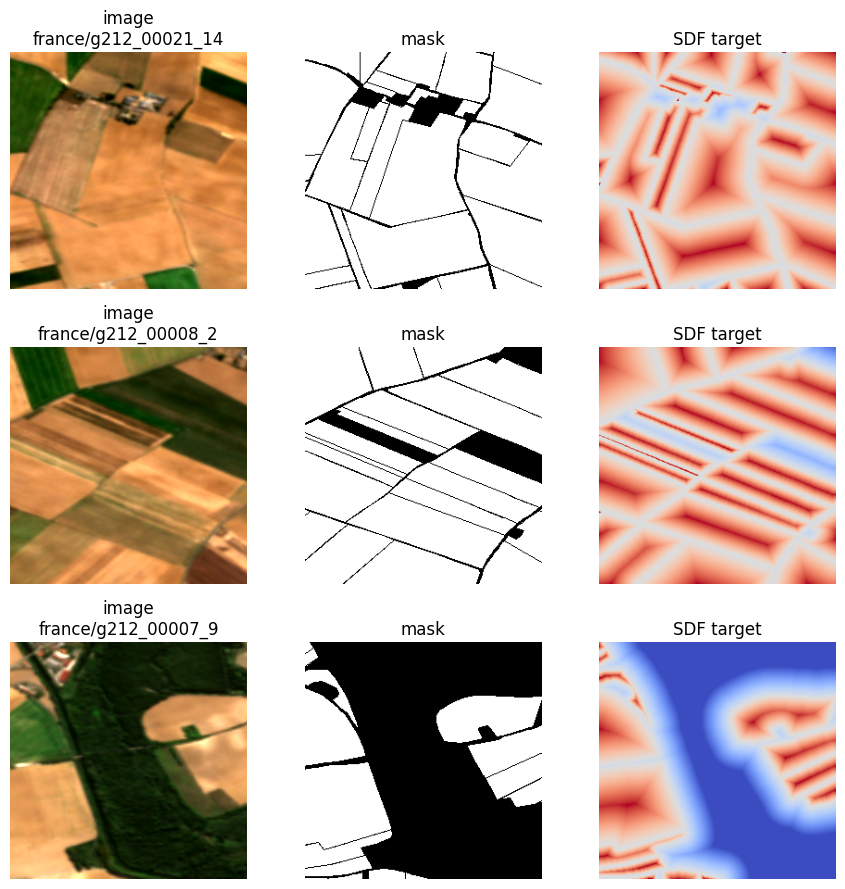

In [26]:
data_module = config['datamodule'](**config['data_args'])
train_loader = data_module.get_loader()
valid_loader = data_module.get_heldout_loader()

batch = next(iter(train_loader))
print('Batch image shape:', tuple(batch['image'].shape))
print('Batch mask shape:', tuple(batch['mask'].shape))
print('Batch distance shape:', tuple(batch['distance'].shape))
print('Example IDs:', batch.get('id', [])[:3])

print("Train images:", len(train_loader.dataset))
print("Validation images:", len(valid_loader.dataset))
print("Total images:", len(train_loader.dataset) + len(valid_loader.dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

batch = next(iter(train_loader))
{k: v.shape if hasattr(v, "shape") else v[:3] for k, v in batch.items()}

show_batch(batch, max_items=3);

## Train

This cell trains the selected config and writes logs/checkpoints under `Logs/` and `Saved/`. The default synthetic run is only two epochs; real FTW configs are longer.

In [27]:
trainer = config['trainer_module'](
    config=config,
    log_dir=PROJECT_ROOT / 'Logs',
    train_loader=train_loader,
    eval_loader=valid_loader,
)
history = trainer.train()
history[-1]

INFO:ftw_mask_baseline:MaskOnlyUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=

Epoch 1:   0%|          | 0/101 [00:00<?, ?it/s]

: 

## Evaluate

Run one heldout evaluation pass after training. For the project claim, compare `ftw_mask_baseline` and `ftw_dual_head` on the same data split.

In [ ]:
eval_result = trainer.evaluate(valid_loader)
eval_result

## Visualize Predictions

In [ ]:
batch = next(iter(valid_loader))
has_sdf_head = 'distance_logits' in trainer.model(batch['image'][:1].to(trainer.device))
show_predictions(
    trainer.model,
    batch,
    device=trainer.device,
    max_items=3,
    use_sdf_instances=has_sdf_head,
);

## Checkpoints

Best and last model weights are saved under `Saved/<experiment_name>/best_model.pth` and `Saved/<experiment_name>/last_model.pth`. Use `visualize_predictions.py` or `evaluate_checkpoints.py` to reuse those checkpoints without retraining.